# Linear transformations and 2D shape manipulation using Python

### 1. Introduction
In computer graphics and data science, manipulating shapes and images is a fundamental task. Whether we are spinning a character or resizing a photo we use linear algebra to make it happen.
The objective of this project is to show how to change 2D shapes using matrices. We will explore three main moves: 
1. Rotation: spinning the shape around a point
2. Scaling: changing the size of the shape
3. Shearing: distorting the object along an axis
4. Matrix composition: combining multiple steps into one single transformation matrix

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Define a simple shape (house)
# Each column is a point (x, y)
shape = np.array([
    [0, 0], [2, 0], [2, 2], [1, 3], [0, 2], [0, 0]
]).T 

### 2. Visualization Logic
Before we apply any transformations we need a consistent way to visualize our results. We will create a helper function plot_shape that allows us to compare the original shape with its transformed version.
Key features of this function:
1. Original vs. transformed: it plots the original coordinates as a faded dashed line (alpha=0.3) and the new coordinates as a solid blue line.
2. Grid and axes: it includes the **X** and **Y** axes to show the origin (0, 0), which is the center for most transformations like rotation.
3. Equal scaling: I use *plt.axis('equal')* to ensure that 1 unit on the X-axis is the same length as 1 unit on the Y-axis. Without scaling it, a square might look like a rectangle, and our rotations would look distorted.


In [5]:
def plot_shape(original, transformed, title):
    plt.figure(figsize=(6,6))
    plt.plot(original[0, :], original[1, :], 'b--', label='Original')
    plt.plot(transformed[0, :], transformed[1, :], 'r-', linewidth=2, label='Transformed')
    plt.axhline(0, color='black', lw=1)
    plt.axvline(0, color='black', lw=1)
    plt.grid(True, linestyle=':')
    plt.legend()
    plt.title(title)
    plt.axis('equal')
    plt.show()

### 3. Scaling transformation
Scaling is a linear transformation that enlarges or shrinks objects. It is represented by a diagonal matrix where the diagonal elements determine the scale factor for each axis:
$$S = \begin{pmatrix} s_x & 0 \\ 0 & s_y \end{pmatrix}$$
If $s_x = s_y$, the scaling is uniform. If $s_x \neq s_y$, the shape will be stretched or squashed.

When we multiply a point *(x, y)* by this matrix, the transformation scales each coordinate independently:
$$x' = s_x \cdot x$$
$$y' = s_y \cdot y$$

This shows that the transformation is a linear mapping where the origin (0, 0) always remains fixed (the "center" of the scaling).


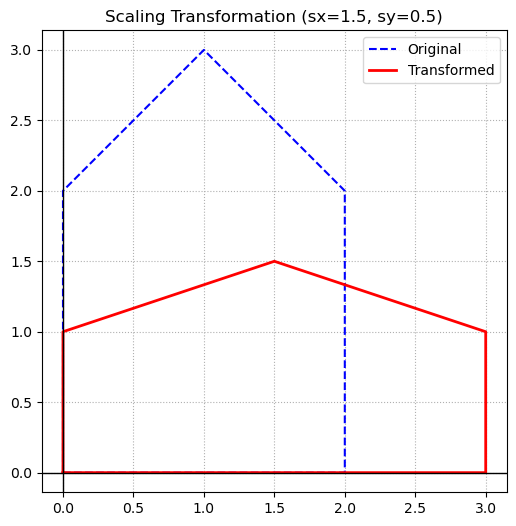

In [17]:
scaled_x, scaled_y = 1.5, 0.5
S = np.array([[scaled_x, 0], 
              [0, scaled_y]])
scaled_shape = S @ shape 

plot_shape(shape, scaled_shape, f"Scaling Transformation (sx={scaled_x}, sy={scaled_y})")

### 4. Rotating the shape
After scaling the next fundamental transformation is **rotation**. Unlike scaling which changes the size, rotation changes the orientation of our object by "spinning" it around a fixed point.

**The mathematics of rotation**

To rotate a point *(x, y) in a 2D space by an angle $\theta$ around origin (0, 0), we use a **rotation matrix**.
The standard matrix for a counter-clockwise rotation is:
$$R = \begin{pmatrix} \cos \theta & -\sin \theta \\ \sin \theta & \cos \theta \end{pmatrix}$$

When we multiply our shape coordinates by this matrix, each point is transformed to a new position:
$$x_{new} = x \cdot \cos \theta - y \cdot \sin \theta$$
$$y_{new} = x \cdot \sin \theta + y \cdot \cos \theta$$


**Implementation details**

Computers (and the numpy library) think in radians, not degrees. We must convert our 45° angle using np.radians(45) before building the matrix.

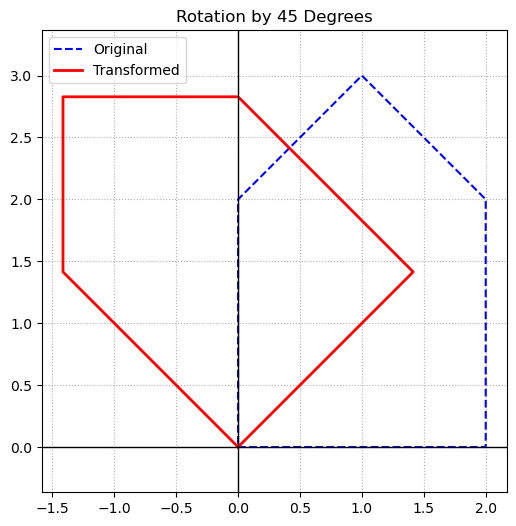

In [16]:
theta = np.radians(45)
rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
rotated_shape = rotation_matrix @ shape

plot_shape(shape, rotated_shape, "Rotation by 45 Degrees")

### 5. Shearing transformation
The third type of linear transformation we will explore is **shearing**. While scaling changes size and rotation changes orientation, shearing *slants* the object.
In a horizontal shear the *y*-coordinate of a point remains the same, but the 
*x*-coordinate changes proportionally to its distance from the x-axis.
The **shear matrix** for the x-axis is:
$$H = \begin{pmatrix} 1 & k \\ 0 & 1 \end{pmatrix}$$

Where ***k*** is the shear factor. The transformation equations are:
\begin{gather*}
x_{new} = x + k \cdot y \\
y_{new} = y
\end{gather*}



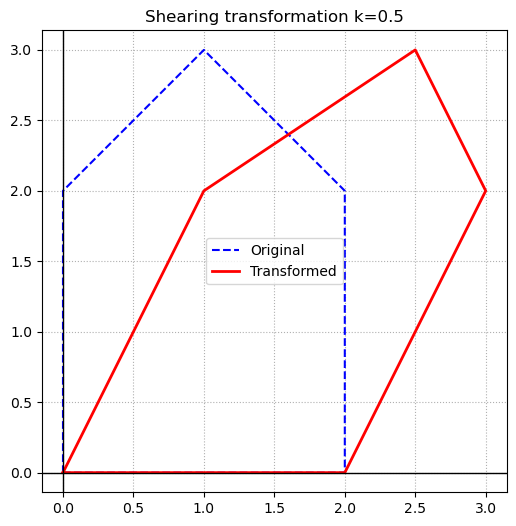

In [19]:
k = 0.5 
shear_matrix = np.array([[1, k],
              [0, 1]])

sheared_shape = shear_matrix @ shape
plot_shape(shape, sheared_shape, "Shearing transformation k=0.5")

**Analysis:**

* The base of the house remains at its original position.
* The roof being the highest part of the shape, moved the most horizontally.
* The vertical lines are now tilted, but they stay parallel to each other.

### 6. Matrix composition
In mathematics when we multiply numbers the order doesn't matter. However, for matrix transformations the order is critic.
As seen in the plots above, we tested two scenarios:
1. Scenario A scaling then rotation: We first stretch the house and then rotate it.
2. Scenario B rotation then scaling: We first rotate the house and then stretch it.


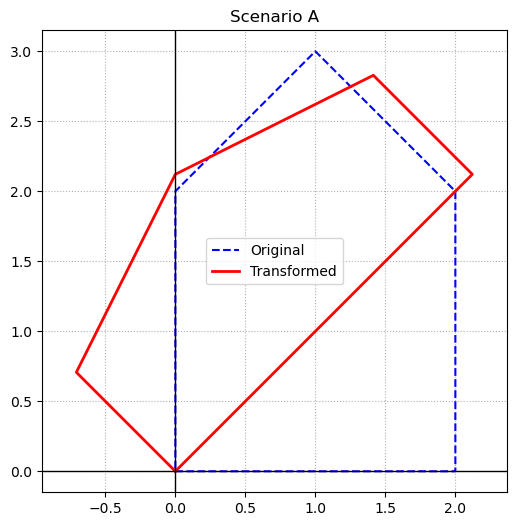

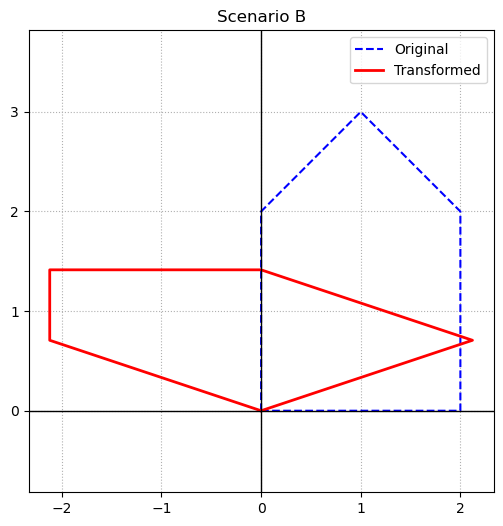

In [23]:
shape_A = rotation_matrix @ (S @ shape)
plot_shape(shape, shape_A, "Scenario A")

shape_B = S @ (rotation_matrix @ shape)
plot_shape(shape, shape_B, "Scenario B")

**Analysis**

* We see different results. Even though we used the exact same matrices ***rotation_matrix*** and ***S***, the final shapes look completely different.
* Мatrix multiplication is non-commutative. This means that rotating then scaling is not the same as scaling then rotating. The examples above prove that $R \cdot S \neq S \cdot R$
* Scaling always stretches the space along the grid's *x* and *y* lines. If we rotate the house first, its own axes no longer line up with the grid. Therefore, scaling it after rotation stretches it diagonally, creating a distorted effect.
